In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from mpl_toolkits.mplot3d import Axes3D
import os
from sklearn.decomposition import PCA
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['font.sans-serif'] = ['Helvetica']  # ensures fallback


colors_list = ["#161347","#304c99", "#62a1db", "#e7d87d", "#dd9f40", "#b4451f", "#b01111","#7a0808","#4f0000"]
cmap = LinearSegmentedColormap.from_list("reinterpret_map", colors_list, N=256)


In [2]:
current_directory = os.getcwd()

file_path = os.path.join(
    current_directory,
    "../../data/subject_by_node_Viewing1_Viewing2_subs_schaefer_rois.csv"
)

data = pd.read_csv(file_path)


In [3]:
# Keep only experimental condition
data = data[data["Condition"] == "expt"]

# Rename to match R logic
data["appraisal_self"]  = data["appraisal_SELF_cond1"]
data["appraisal_other"] = data["appraisal_OTHER_cond1"]

# Semantic distance = 1 - cosine similarity
data["semantic_distance"] = 1 - data["cosine_sim_avg_inputs_BERT_context_miniLM_L6"]

# Only node 41
data_full = data[data["Node_Number"] == 41].copy()


In [8]:
data_full["confidence_scaled"]      = data_full["confidence"] / 100
data_full["appraisal_self_scaled"]  = data_full["appraisal_SELF_cond1"] / 100
data_full["appraisal_other_scaled"] = data_full["appraisal_OTHER_cond1"] / 100

data_full["reinterpretation"] = (
    data_full["confidence_scaled"]
    - data_full["appraisal_self_scaled"]
    + data_full["appraisal_other_scaled"]
)


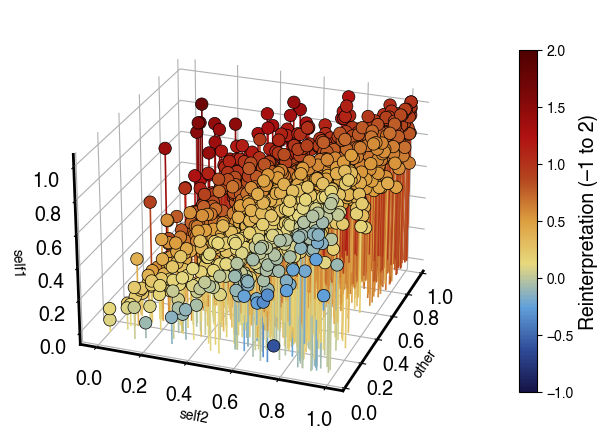

In [ ]:
# Fixed normalization range
norm = Normalize(vmin=-1, vmax=2)
y = data_full["appraisal_self_scaled"].values
z = data_full["confidence_scaled"].values
x = data_full["appraisal_other_scaled"].values
c = data_full["reinterpretation"].values

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
# Make 3D background white instead of gray
ax.w_xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.w_yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.w_zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))

# Also remove the darker gridlines on panes if desired
ax.w_xaxis.line.set_color("black")
ax.w_yaxis.line.set_color("black")
ax.w_zaxis.line.set_color("black")
ax.w_xaxis.line.set_linewidth(2)
ax.w_yaxis.line.set_linewidth(2)
ax.w_zaxis.line.set_linewidth(2)
#ax.view_init(elev=20, azim=15)
ax.view_init(elev=25, azim=20)
ax.set_xlim(1, 0)



sc = ax.scatter(
    x, y, z,
    c=c,
    cmap=cmap,
    norm=norm,
    s=80,
    edgecolor='k',
    linewidth=0.5,
    alpha = 1,
)
# Draw vertical projection lines
for xi, yi, zi, ci in zip(x, y, z, c):
    ax.plot(
        [xi, xi],       #vertical
        [yi, yi],        
        [0, zi],         # z from bottom plane → point height
        color=cmap(norm(ci)),
        linewidth=1.2,
        alpha=1
    )
ax.tick_params(axis='both', which='major', labelsize=14)



ax.set_xlabel("other")
ax.set_ylabel("self2")
ax.set_zlabel("self1")

cbar = plt.colorbar(sc, pad=0.1,    orientation="vertical", shrink=.6)

cbar.set_label("Reinterpretation (–1 to 2)", fontsize=14)



plt.tight_layout()
plt.savefig("../../results/reinterpretation_plots/reinterpretation_3D_scatter.pdf",transparent=True)
plt.show()

# Testing the PCA (put in the Methods section)

In [13]:

# Select behavioral variables
X = data_full[
    ["appraisal_self_scaled",
     "confidence_scaled",
     "appraisal_other_scaled"]
]

# remove inf values
X = X.replace([np.inf, -np.inf], np.nan)

# remove missing rows
X = X.dropna()

# keep matching rows
data_clean = data_full.loc[X.index]

# convert to numpy
X = X.values

pca = PCA()

embedding = pca.fit_transform(X)

print("Variance explained:", pca.explained_variance_ratio_)

pc1 = embedding[:,0]
pc2 = embedding[:,1]
pc3 = embedding[:,2]

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1","PC2","PC3"],
    index=["Self","Confidence","Other"]
)

print(loadings)

Variance explained: [0.56372358 0.34841076 0.08786567]
                 PC1       PC2       PC3
Self       -0.663347  0.320025 -0.676428
Confidence -0.631278  0.246065  0.735486
Other      -0.401819 -0.914897 -0.038798


In [14]:
corr_pc2 = np.corrcoef(pc2, data_clean["reinterpretation"])[0,1]

if corr_pc2 < 0:
    pc2 = -pc2
    loadings["PC2"] = -loadings["PC2"]
    
pc1 = -pc1
loadings["PC1"] = -loadings["PC1"] #flipping one too so that higher magnitude is higher
    
print(np.corrcoef(pc1, data_clean["reinterpretation"])[0,1])

print(np.corrcoef(pc2, data_clean["reinterpretation"])[0,1])

0.36345334915610283
0.7641642306152326


In [15]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1","PC2","PC3"],
    index=["Self","Confidence","Other"]
)

print(loadings)

print(np.corrcoef(pc1, data_clean["reinterpretation"])[0,1])
print(np.corrcoef(pc2, data_clean["reinterpretation"])[0,1])


                 PC1       PC2       PC3
Self        0.663347 -0.320025 -0.676428
Confidence  0.631278 -0.246065  0.735486
Other       0.401819  0.914897 -0.038798
0.36345334915610283
0.7641642306152326
